
=== FULL RISK METRICS DASHBOARD (2023–2025) ===
Strategy   RL Agent  Rule-Based    NIFTY
CAGR (%)    -3.4300     -8.5900  13.3700
Vol (%)      6.1200     10.2500  12.0100
Sharpe      -1.6035     -1.4593   0.5640
Sortino     -1.4222     -1.8782   0.7778
Calmar      -0.2279     -0.2702   0.8531
Omega        0.8518      0.8483   1.2102
VaR 95%     -0.6600     -1.1100  -1.1000
VaR 99%     -1.1300     -1.9000  -1.6100
CVaR 95%    -1.0300     -1.6400  -1.6400
CVaR 99%    -1.7000     -2.5500  -2.6600
MaxDD (%)  -15.0700    -31.8000 -15.6700

📝 CVaR Interpretation (copy into paper):
CVaR captures the expected loss in the worst 5% (or 1%) of cases, providing a more conservative and realistic risk estimate than VaR.


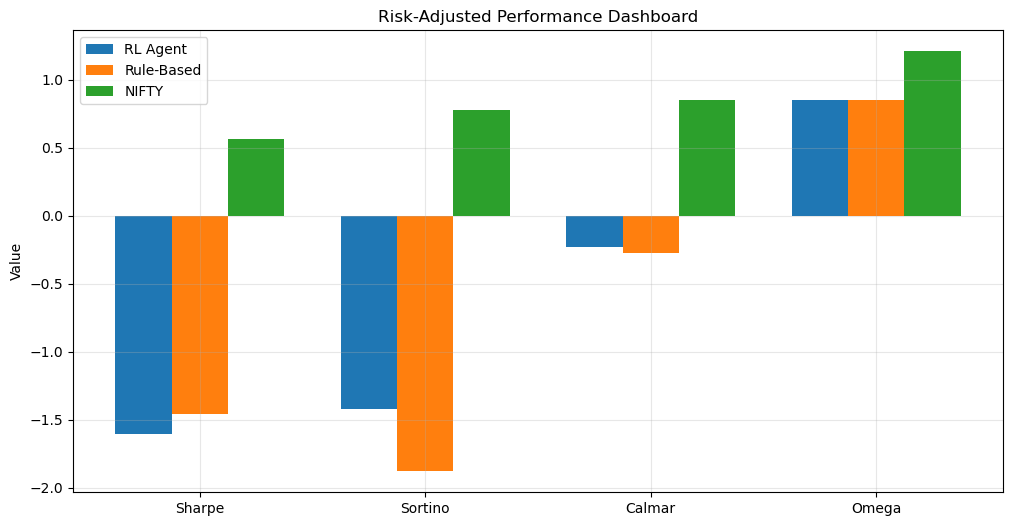

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. FINAL DQN MODEL
class DQN(nn.Module):
    def __init__(self, state_size=7, action_size=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64, action_size)
        )
    def forward(self, x):
        return self.net(x)

policy_net = DQN().to(device)
policy_net.load_state_dict(torch.load("../models/quantum_alpha_final.pth", map_location=device))
policy_net.eval()

# 2. ENVIRONMENT
class QuantumAlphaEnv:
    def __init__(self, data):
        self.data = data.reset_index(drop=True)
        self.feature_cols = ["mom_20_norm", "vol_signal_norm", "trend_signal_norm",
                             "dd_signal_norm", "vix_signal_norm", "breadth_signal_norm"]
        self.max_steps = len(self.data) - 1
        self.reset()
   
    def reset(self):
        self.current_step = 0
        self.position = 0
        self.balance = 1.0
        return self._get_observation()
   
    def _get_observation(self):
        row = self.data.iloc[self.current_step]
        obs = row[self.feature_cols].values.astype(np.float32)
        return np.append(obs, self.position)
   
    def step(self, action):
        prev_position = self.position
        new_position = {0: 0, 1: 1, 2: -1}[action]
        ret = self.data.iloc[self.current_step]["nifty_ret"]
        cost = abs(new_position - prev_position) * 0.0005
        net_ret = prev_position * ret - cost
        self.balance *= (1 + net_ret)
        self.position = new_position
        self.current_step += 1
        done = self.current_step >= self.max_steps
        return self._get_observation(), net_ret, done, {"net_ret": net_ret, "position": self.position}

# 3. RUN RL AGENT
test_data = pd.read_csv("../data/state_dataset.csv", index_col="Date", parse_dates=True)
test_data = test_data.join(pd.read_csv("../data/market_master.csv", index_col="Date", parse_dates=True)[["nifty_ret"]])
test_data = test_data.loc["2023":"2025"]

env = QuantumAlphaEnv(test_data)
state = env.reset()
done = False
equity = 1.0
equity_curve = [1.0]
returns = []

while not done:
    with torch.no_grad():
        s = torch.FloatTensor(state).unsqueeze(0).to(device)
        action = policy_net(s).argmax().item()
    next_state, _, done, info = env.step(action)
    equity *= (1 + info["net_ret"])
    equity_curve.append(equity)
    returns.append(info["net_ret"])
    state = next_state

rl_equity = np.array(equity_curve)
rl_returns = np.array(returns)

# 4. RULE-BASED & NIFTY
rule = pd.read_csv("../backtesting/market_backtest_v7.csv", index_col=0)
rule.index = pd.to_datetime(rule.index)
rule = rule.loc["2023":"2025"]
rule_equity = (1 + rule["strategy_ret_v2"]).cumprod().values
rule_returns = rule["strategy_ret_v2"].values

nifty_equity = (1 + test_data["nifty_ret"]).cumprod().values
nifty_returns = test_data["nifty_ret"].values

# 5. FULL RISK METRICS DASHBOARD (with proper Omega threshold)
def risk_metrics(returns_arr, equity_arr, name=""):
    days = len(returns_arr)
    cagr = equity_arr[-1] ** (252 / days) - 1
    vol = np.std(returns_arr) * np.sqrt(252)
    rf_daily = 0.065 / 252
    sharpe = (np.mean(returns_arr) - rf_daily) / (np.std(returns_arr) + 1e-8) * np.sqrt(252)
    
    downside = returns_arr[returns_arr < 0]
    sortino = (np.mean(returns_arr) - rf_daily) / (np.std(downside) + 1e-8) * np.sqrt(252) if len(downside) > 0 else 0
    
    max_dd = (equity_arr / np.maximum.accumulate(equity_arr) - 1).min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0
    
    # Omega Ratio — proper risk-free threshold
    threshold = rf_daily
    gains = returns_arr[returns_arr > threshold]
    losses = np.abs(returns_arr[returns_arr < threshold])
    omega = np.sum(gains) / np.sum(losses) if np.sum(losses) > 0 else np.inf
    
    # VaR & CVaR
    var_95 = np.percentile(returns_arr, 5)
    var_99 = np.percentile(returns_arr, 1)
    cvar_95 = returns_arr[returns_arr <= var_95].mean()
    cvar_99 = returns_arr[returns_arr <= var_99].mean()
    
    return {
        "Strategy": name,
        "CAGR (%)": round(cagr*100, 2),
        "Vol (%)": round(vol*100, 2),
        "Sharpe": round(sharpe, 4),
        "Sortino": round(sortino, 4),
        "Calmar": round(calmar, 4),
        "Omega": round(omega, 4),
        "VaR 95%": round(var_95*100, 2),
        "VaR 99%": round(var_99*100, 2),
        "CVaR 95%": round(cvar_95*100, 2),
        "CVaR 99%": round(cvar_99*100, 2),
        "MaxDD (%)": round(max_dd*100, 2)
    }

rl_metrics   = risk_metrics(rl_returns, rl_equity, "RL Agent")
rule_metrics = risk_metrics(rule_returns, rule_equity, "Rule-Based")
nifty_metrics = risk_metrics(nifty_returns, nifty_equity, "NIFTY")

dashboard = pd.DataFrame([rl_metrics, rule_metrics, nifty_metrics])
print("\n=== FULL RISK METRICS DASHBOARD (2023–2025) ===")
print(dashboard.set_index("Strategy").T)

print("\n📝 CVaR Interpretation (copy into paper):")
print("CVaR captures the expected loss in the worst 5% (or 1%) of cases, providing a more conservative and realistic risk estimate than VaR.")

# Simple bar dashboard for visual
metrics_plot = ["Sharpe", "Sortino", "Calmar", "Omega"]
rl_vals = [rl_metrics[m] for m in metrics_plot]
rule_vals = [rule_metrics[m] for m in metrics_plot]
nifty_vals = [nifty_metrics[m] for m in metrics_plot]

x = np.arange(len(metrics_plot))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, rl_vals, width, label="RL Agent", color="#1f77b4")
plt.bar(x, rule_vals, width, label="Rule-Based", color="#ff7f0e")
plt.bar(x + width, nifty_vals, width, label="NIFTY", color="#2ca02c")
plt.xticks(x, metrics_plot)
plt.ylabel("Value")
plt.title("Risk-Adjusted Performance Dashboard")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()